# DSE 207R FINAL PROJECT
## By John Naughton , Video Game Sales Dataset from Kaggle
## Winter 2025
### Due Date:  March 16th, 2024
### Late Due Date:  March 18th, 2024

The final project is a guided project for you to build your own end-to-end analysis using Python, especially using what you learned on Python _numpy_, _pandas_, _matplotlib_/_seaborn_ and _scilitlearn_ libraries.

This project is culmination of all you’ve learned in this course! You should expect to spend <b>24-32 total hours</b> on the project. Be sure to read all of the items below before starting. Make sure to follow Piazza for any updates on the final project.

# <b>Deliverables</b>:
The final project has 2 submissions - a report (this notebook) and an presentation video (self recorded). You will be evaluated on both the components.

## 1. Report (this notebook)
Submit the notebook via Gradescope by midnight on the due date above along with clear instructions on how to download the datasets you used for and reproduce your results. You can host the dataset (on GitHub) such that it can be used as a URL directly. Don't forget to add your name on top as the author of the notebook.



There are a number of steps outlined below, but is critical that you do not view this as an entirely linear process.  Remember that the science component in data science is the creation of a hypothesis based on exploration and testing of that hypothesis through analysis.  You may need to go through many of these steps multiple times before you arrive at meaningful hypothesis or conclusions.

### Step 1: Find a dataset or datasets

1.1. **Based on your interest, identify a dataset which you will want to examine.**  You will find a starting point for where you can find open datasets at the end of this notebook, but feel free to use other datasets you have access to and can publicly share results about.


This step may take some time, as you’ll likely look at a number of datasets before you find one (or more) which holds promising data for the kinds of questions you want to ask.

Below are some resources but you are not limited to them -

UCI's Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets.php <br>
Kaggle: https://www.kaggle.com/datasets <br>
KDnuggets Dataset: http://www.kdnuggets.com/datasets/index.html <br>
government data (http://www.kdnuggets.com/datasets/government-local-public.html) <br>
Data APIs (http://www.kdnuggets.com/datasets/api-hub-marketplace-platform.html <br>
Data Mining Competitions (http://www.kdnuggets.com/competitions/index.html <br>
US Government Data: https://www.data.gov/ <br>
UK Government Data: https://data.gov.uk/ <br>
Canada's Open Data Exchange: https://codx.ca/ <br>
World Health Organization: http://www.who.int/gho/en <br>
World Bank: http://data.worldbank.org/ <br>

Remember! Finding a dataset of interest and exploring it is most of your job for your final project. So expect this to take some time - and that's both perfectly normal and completely okay. Get started early and make sure to check if the dataset you find satisfies the project requirements.
<br>

<br>

1.2. **Once selected, explain the choice of dataset and why you want to work with it.**

In [ ]:
# For this project I wanted to choose a very large data set about a concept I was fairly familiar with,
# so I chose the Video Games Sales Dataset from Kaggle, using data scraped from Metacritic. The dataset contains 16 variables describing 16,719 video games
# that were released from 1980 to 2020. The variables describe the games themselves, like Name, Gaming Platform, Genre, Rating, and Year of Release,
# and also describe how well the game performed, including variables like Global Sales, Critic Scores, and User Scores.
# The dataset is ordered by global sales, and the large dataset (16k games) and is extremely right skewed in the sales data, ie the majority of games sold very poorly while
# a handful of games sold very well, requiring some data transformations. There was a large amount of data missingness which
# was an interesting challenge and I discuss in section 2.1. I wanted to work with this dataset to understand the overall gaming environment of the last 45 years.
# I believe I have enough knowledge of the variables and environment to ask some interesting research questions that could produce valuable insights.

# First we import the file from Googledrive, and print the dimensions and first four rows to check our top four selling games
import pandas as pd
import numpy as np
file_id = "1syz3k1xZ_0kXj24-DYUnVKB80oFmbuBc"
download_link = f"https://drive.google.com/uc?export=download&id={file_id}"
gamesdf = pd.read_csv(download_link)
print(gamesdf.shape)
gamesdf.head(4)


(16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E


In [ ]:
# Next we print the info and describe in pandas, to see we have 6 character variables and 10 numerical variables.
gamesdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       7590 non-null   float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(10), object(6)
memory usage: 2.0+ MB


### Step 2: Explore the datasets

In this step, you should explore what is present in the data and how the data is organized.

You are expected to answer the following questions using the _pandas_ library and markdown cells to describe your actions:

* Are there quality issues in the dataset (noisy, missing data, etc.)?
* What will you need to do to clean and/or transform the raw data for analysis?

You can also visually explore the datasets and explain your findings, specifically,

* How are the data distributed?
* What are some common trends?

In [ ]:
# 2.1 Are there quality issues in the dataset? What will you need to do to clean and/or transform the raw data for analysis?
# First we tackle the missing values in our dataset, and see that we have two distinct problems.
#First we print missing values by column
missing_values = gamesdf.isnull().sum()
print("Number of missing values in each column:")
print(missing_values)
print (gamesdf.shape)


Number of missing values in each column:
Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         9129
User_Count         9129
Developer          6623
Rating             6769
dtype: int64
(16719, 16)


In [ ]:
# We have a tiny bit of missingness in the Name, Year, Genre and Publisher variables (less than 1%)
# but a huge amount of missingness in the Score/Developer/Rating variables (about HALf of our data).
# I've decided to handle this missingness in two seperate ways. For the first, we will simply delete these rows, they
# are for relatively insinificant values anyways. We store them in the dataframe upgamesdf

upgamesdf = gamesdf.dropna(subset=['Name', 'Year_of_Release', 'Genre', 'Publisher'])
print(f"gamesdf size: {gamesdf.shape}")
print(f"upgamesdf size: {upgamesdf.shape}")
print(f"we removed {gamesdf.shape[0] - upgamesdf.shape[0]} rows")


#For the second problem, we notice that the majority of the Score/Developer/Rating
# missingness occurs in games that are on the lower end of global sales, which makes sense because games that did not sell well
# are less likely to be critically reviewed, get an official developer, and get rated. However, these games can still be valuable to our conclusions,
# so we will leave this half of the data in our dataset, while noting that any conclusions drawn from those 6 variables include
# large amounts of missing data and may thus be not as robust.

gamesdf size: (16719, 16)
upgamesdf size: (16416, 16)
we removed 303 rows


In [ ]:
# Third we need to make some transformations to some of our raw data. We see in 2.2 that
# while numerical variables Year_of_Release, Critic_Score, Critic_Count, and User_Score all have clean distributions,
# our other 6 numerical variables 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', and 'User_Count'
# are all extremely right skewed. The Sales and User counts are mostly clustered around small values, while a few extremely
# well selling games are extreme ourliers on the upper end (big hits like Super Mario, Pokemon, Wii sports, etc.)
# Below we print the mean/stds/quartiles to confirm this.
print(upgamesdf.describe())

       Year_of_Release      NA_Sales      EU_Sales      JP_Sales  \
count     16416.000000  16416.000000  16416.000000  16416.000000   
mean       2006.489888      0.264129      0.146034      0.078623   
std           5.881148      0.819028      0.507134      0.311348   
min        1980.000000      0.000000      0.000000      0.000000   
25%        2003.000000      0.000000      0.000000      0.000000   
50%        2007.000000      0.080000      0.020000      0.000000   
75%        2010.000000      0.240000      0.110000      0.040000   
max        2020.000000     41.360000     28.960000     10.220000   

        Other_Sales  Global_Sales  Critic_Score  Critic_Count   User_Score  \
count  16416.000000  16416.000000   7982.000000   7982.000000  7461.000000   
mean       0.047670      0.536708     68.997119     26.440992     7.126900   
std        0.188156      1.559885     13.918755     19.009305     1.498886   
min        0.000000      0.010000     13.000000      3.000000     0.000000 

In [ ]:
# the solution to this is to add 6 new variables that are the log transforms of 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', and 'User_Count',
# so that this data can be more readable in histograms and other analyses.
# We add the columns to an updatated dataframe finalgamesdf

finalgamesdf = upgamesdf.copy()
# Adding log-transformed columns
# Using np.log1p which is log(1+x) to handle the numerous zeros in the data
finalgamesdf['log_NA_Sales'] = np.log1p(finalgamesdf['NA_Sales'])
finalgamesdf['log_EU_Sales'] = np.log1p(finalgamesdf['EU_Sales'])
finalgamesdf['log_JP_Sales'] = np.log1p(finalgamesdf['JP_Sales'])
finalgamesdf['log_Other_Sales'] = np.log1p(finalgamesdf['Other_Sales'])
finalgamesdf['log_Global_Sales'] = np.log1p(finalgamesdf['Global_Sales'])
finalgamesdf['log_User_Count'] = np.log1p(finalgamesdf['User_Count'])

# Verify the new columns were added
print(f"Original columns: {len(upgamesdf.columns)}")
print(f"New columns: {len(finalgamesdf.columns)}")
print(f"New log-transformed columns: {[col for col in finalgamesdf.columns if 'log_' in col]}")

Original columns: 16
New columns: 22
New log-transformed columns: ['log_NA_Sales', 'log_EU_Sales', 'log_JP_Sales', 'log_Other_Sales', 'log_Global_Sales', 'log_User_Count']


In [ ]:
# 2.2 How is the data distributed? What are some common trends?

# First we want to look at our 6 categorical variables and see what trends are dominant.
# The variable "Name" contains all unique game titles, so lets look the other 5.

In [ ]:
catcolums = ['Platform', 'Genre', 'Publisher', 'Developer', 'Rating']

for column in catcolums:
    print(f"\nTop 5 most common values in {column}:")
    value_counts = finalgamesdf[column].value_counts().head(5)
    for value, count in value_counts.items():
        print(f"- {value}: {count} ")


Top 5 most common values in Platform:
- PS2: 2127 
- DS: 2122 
- PS3: 1306 
- Wii: 1286 
- X360: 1232 

Top 5 most common values in Genre:
- Action: 3307 
- Sports: 2306 
- Misc: 1697 
- Role-Playing: 1483 
- Shooter: 1296 

Top 5 most common values in Publisher:
- Electronic Arts: 1344 
- Activision: 976 
- Namco Bandai Games: 935 
- Ubisoft: 930 
- Konami Digital Entertainment: 825 

Top 5 most common values in Developer:
- Ubisoft: 201 
- EA Sports: 169 
- EA Canada: 164 
- Konami: 158 
- Capcom: 137 

Top 5 most common values in Rating:
- E: 3921 
- T: 2904 
- M: 1536 
- E10+: 1393 
- EC: 8 


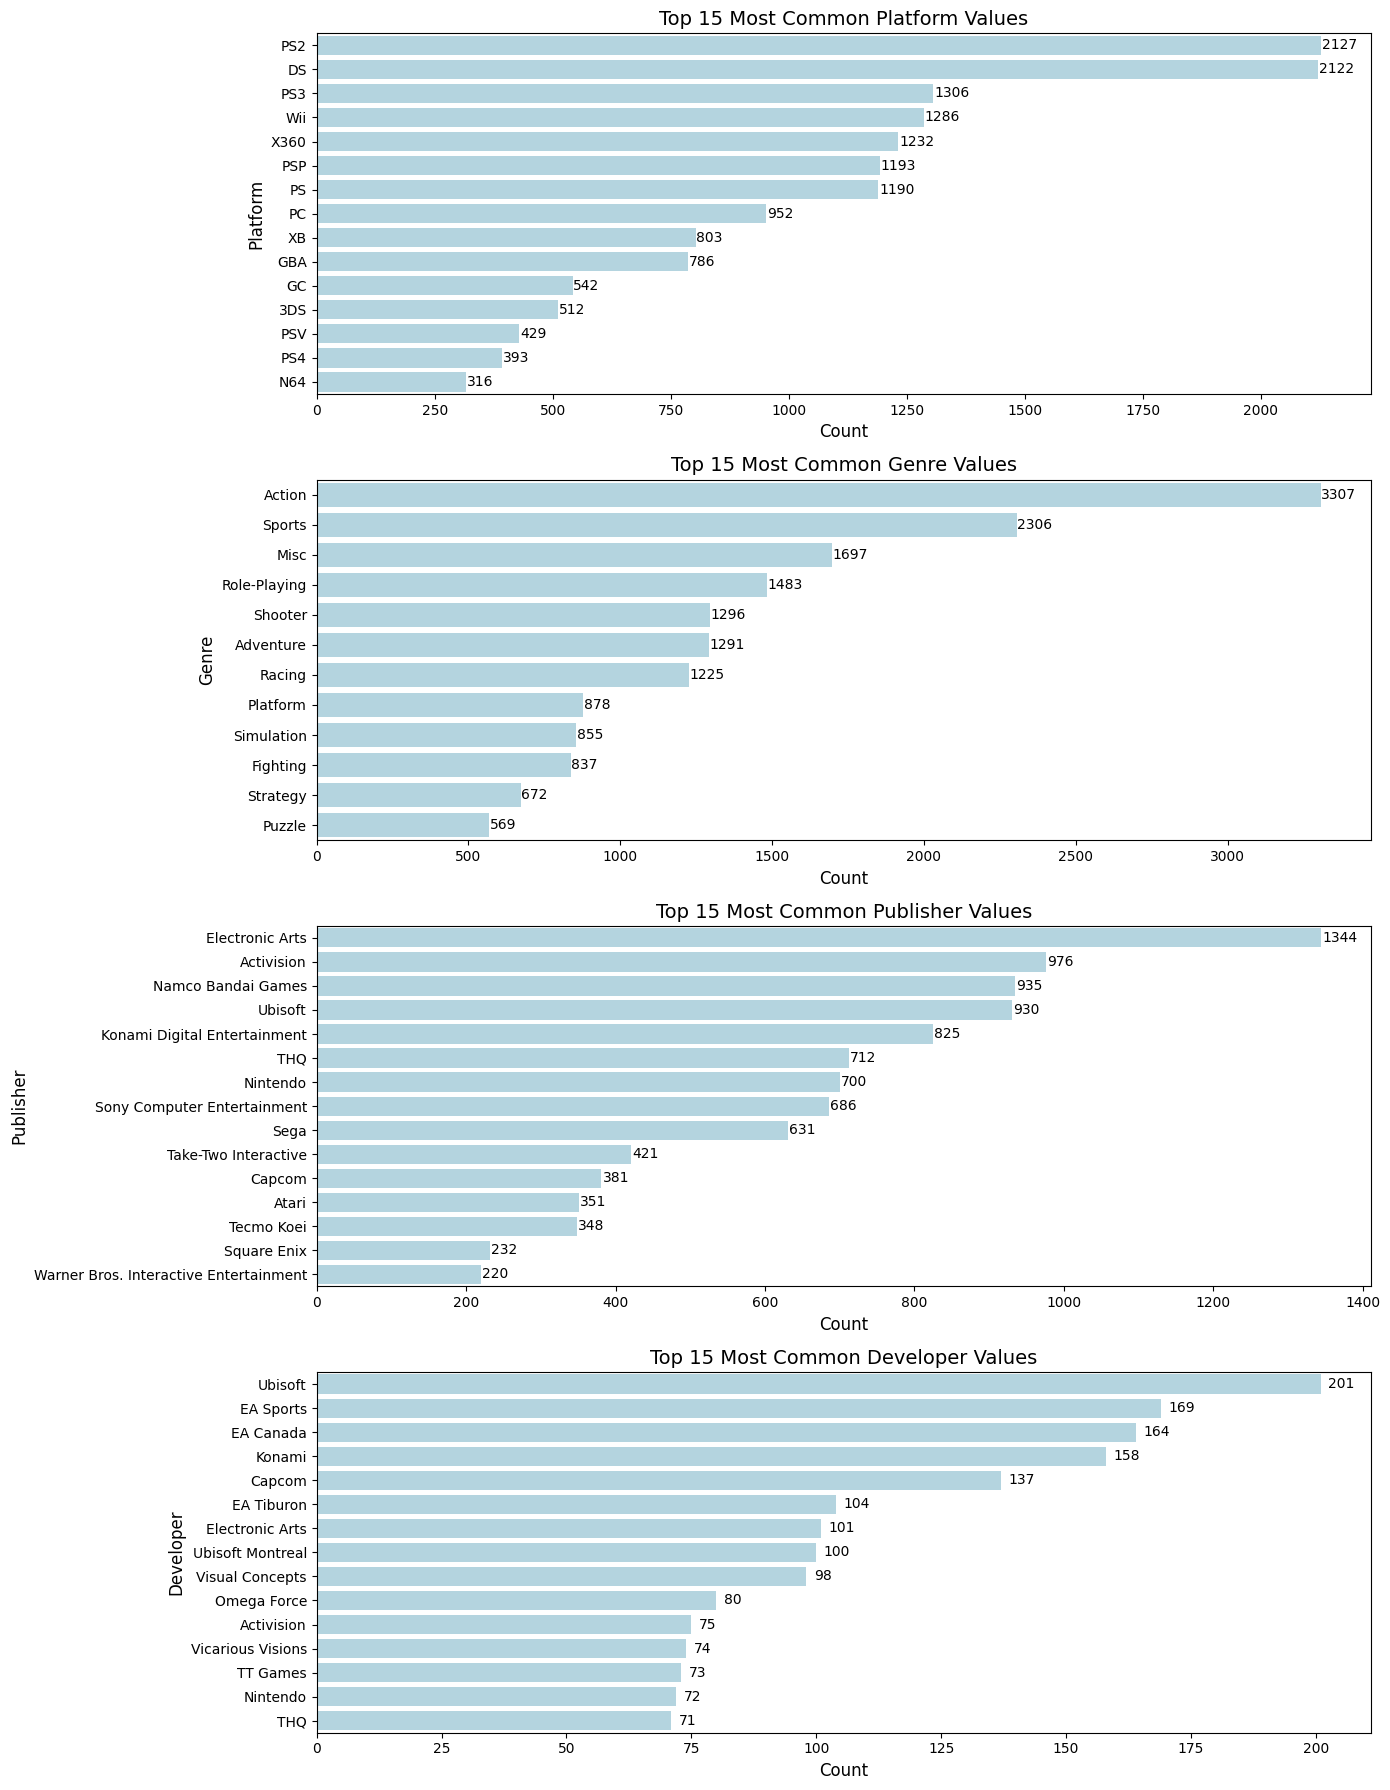

In [ ]:
# We see a quick dropoff in the Rating category (There are only 4 major ratings, E, T, M, E10+)
# but a slow dropoff in the other 4, so lets print histograms of the top 15 values for each of these 4 variables
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 18))

cats = ['Platform', 'Genre', 'Publisher', 'Developer']

# Create a subplot for each categorical variable
for i, column in enumerate(cats):
    plt.subplot(4, 1, i+1)
    top_values = finalgamesdf[column].value_counts().head(15)
    sns.barplot(x=top_values.values, y=top_values.index, color='lightblue')

    # add labels
    plt.title(f'Top 15 Most Common {column} Values', fontsize=14)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel(column, fontsize=12)

    # add nice count labels
    for j, v in enumerate(top_values.values):
        plt.text(v + 1.5, j, str(v), va='center')

plt.tight_layout()
plt.show()

In [ ]:
# We see very healthy distributions in Platforms, Genres, Publishers, and Developers from games released in the last 45 years!
# PS2 and Nintendo DS are the most common platforms, Action games the most released,
# and EA is the most common publisher while Ubisoft is the single most common developer.

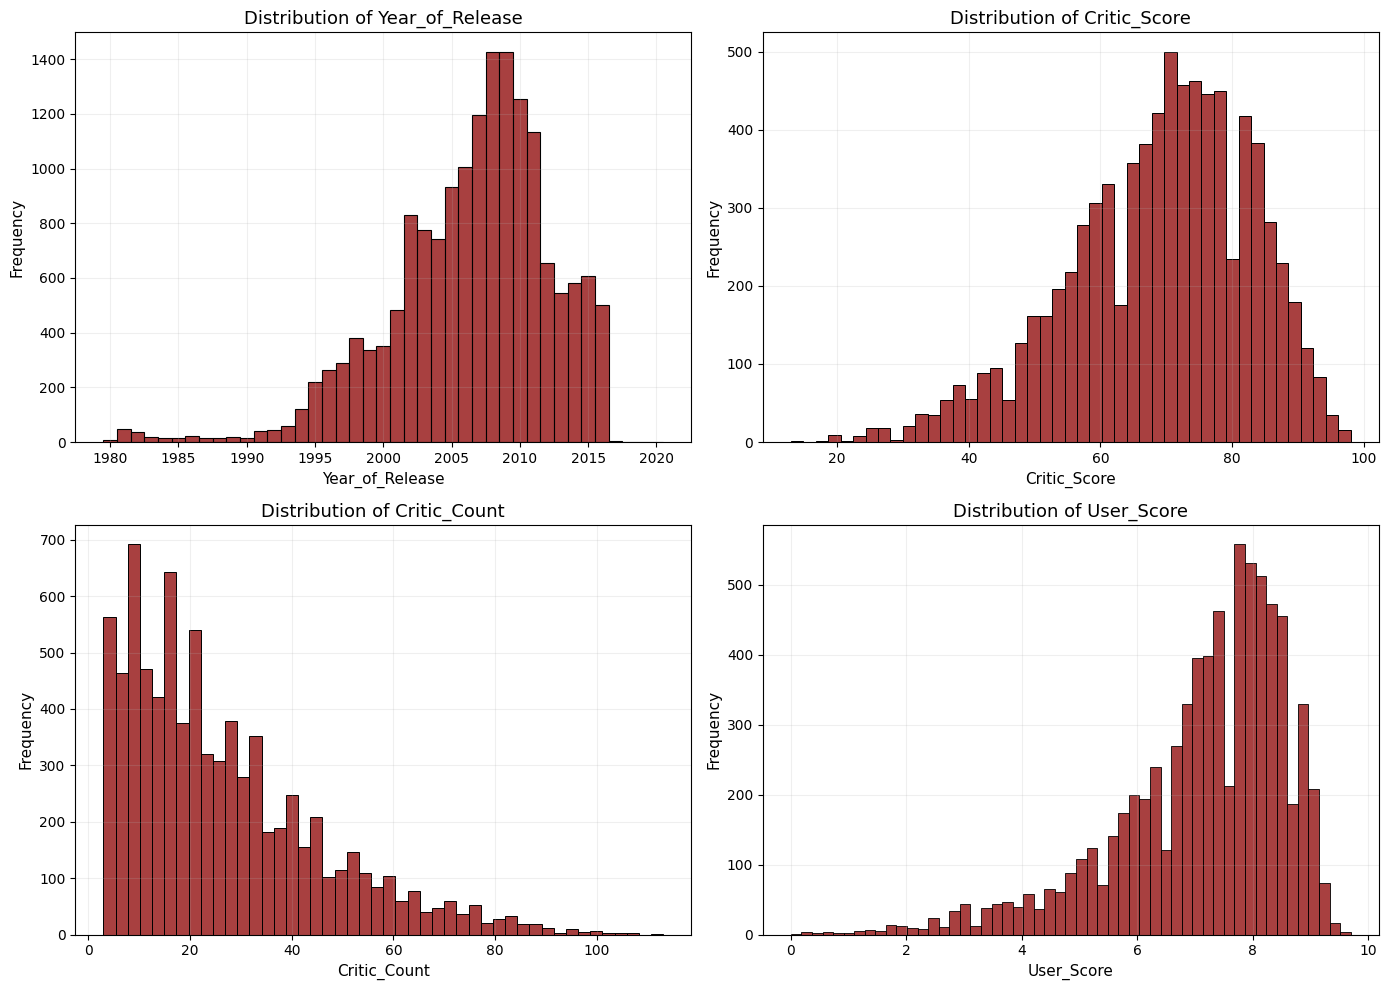

In [ ]:
# Next we want to visualize the distributions of our numerical variables, our first 4 Year_of_Release, Critic_Score, Critic_Count, and User_Score can
# have their distributions displayed cleanly, and we do so below:

plt.figure(figsize=(14, 10))
variables = ['Year_of_Release', 'Critic_Score', 'Critic_Count', 'User_Score']

for i, variable in enumerate(variables):
    plt.subplot(2, 2, i+1)

    if variable == 'Year_of_Release':
        # set bins to each year
        min_year = int(finalgamesdf[variable].min())
        max_year = int(finalgamesdf[variable].max())
        bins = np.arange(min_year, max_year + 2) - 0.5
        sns.histplot(data=finalgamesdf, x=variable, bins=bins, kde=False, color="darkred")
        plt.xticks(np.arange(min_year, max_year + 1, 5))
    else:
        # otherwise normal bins
        sns.histplot(data=finalgamesdf, x=variable, kde=False, color="darkred")

    # add labels
    plt.title(f'Distribution of {variable}', fontsize=13)
    plt.xlabel(variable, fontsize=11)
    plt.ylabel('Frequency', fontsize=11)
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [ ]:
# We see some pretty interesting distributions! I was suprised to see video game releases PEAK in 2008-2009,
# I would have predicted the releases would keep increasing. We can compare our Critic Scores to our User Scores,
# and while both are left skewed, Critic Scores had a mode of about 70% and we not as skewed, while User Scores
# had a mode of about 80% and were more clustered to the right of the distribution. Apprarently critics were less forgiving and more willing
# to give out low scores.

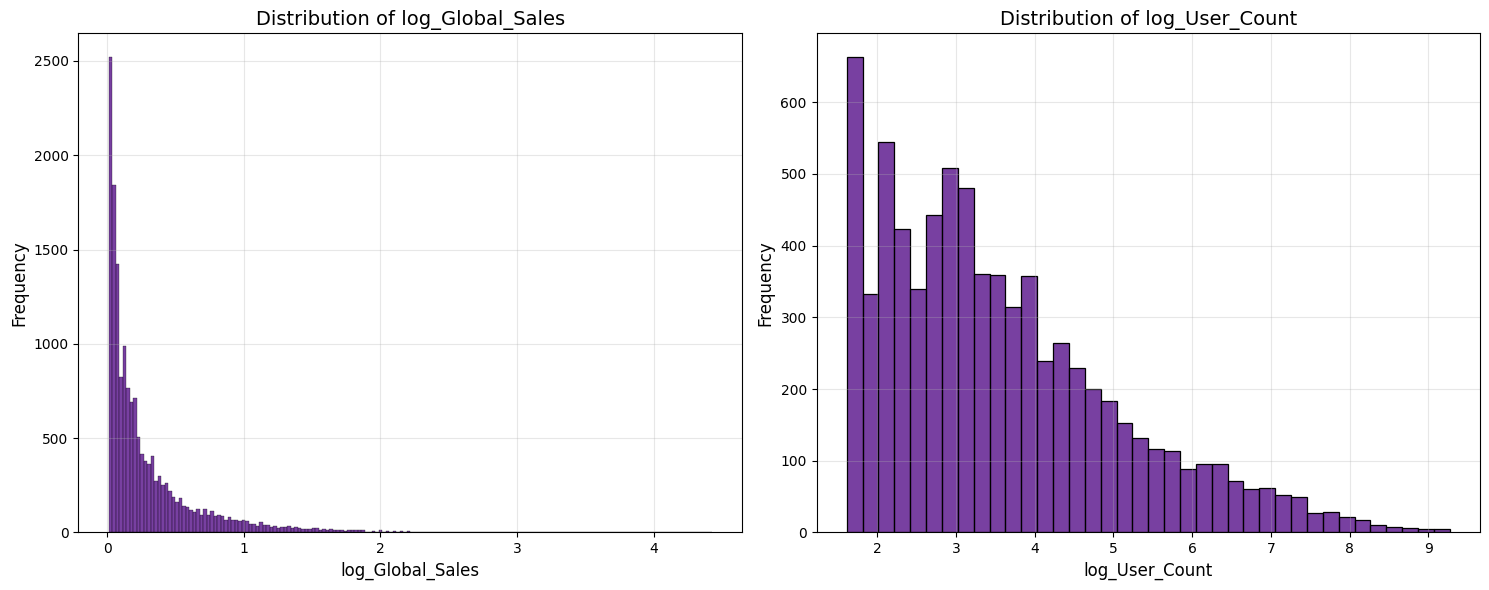

In [ ]:
# Next lets plot the distributions of two of our log transformed variables, Global Sales and User Count.

plt.figure(figsize=(15, 6))
log_variables = ['log_Global_Sales', 'log_User_Count']

for i, variable in enumerate(log_variables):
    plt.subplot(1, 2, i+1)

    sns.histplot(data=finalgamesdf, x=variable, kde=False, color='indigo')

    # add labels, grid
    plt.title(f'Distribution of {variable}', fontsize=14)
    plt.xlabel(variable, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# We see that even AFTER we log transform our sales and user count data, our distributions are still right skewed.
# Global Sales in particular is dominated by games that sold very little, while the bestselling games skew the data on the upper end.

In [ ]:
# I wanted another way to demonstate how skewed the Global_Sales variable was, so here
# is a table of percentiles by every 5%. Extremely unequal distribution!
percentiles = list(range(0, 101, 5))
percentile_values = np.percentile(finalgamesdf['Global_Sales'].dropna(), percentiles)

# Print the results in a readable format
print("Global_Sales Percentiles (every 5%):")
print(f"{'Percentile':>10} | {'Million Dollars of Sales':>12}")
print("-" * 40)

for p, val in zip(percentiles, percentile_values):
    print(f"{p:>10}% | {val:>12.4f}")

Global_Sales Percentiles (every 5%):
Percentile | Million Dollars of Sales
----------------------------------------
         0% |       0.0100
         5% |       0.0200
        10% |       0.0200
        15% |       0.0300
        20% |       0.0500
        25% |       0.0600
        30% |       0.0800
        35% |       0.0900
        40% |       0.1100
        45% |       0.1400
        50% |       0.1700
        55% |       0.2000
        60% |       0.2500
        65% |       0.3000
        70% |       0.3800
        75% |       0.4700
        80% |       0.6000
        85% |       0.8300
        90% |       1.2100
        95% |       2.0500
       100% |      82.5300


In [ ]:
#I wanted one more way to demonstrate the inequality, so we calculate the Gini coefficient for Global_Sales, .7164 is pretty high!

def calculate_gini(variable):
    sorted_values = np.sort(variable.values)
    n = len(sorted_values)
    cumsum = np.cumsum(sorted_values)
    lorenz_curve = cumsum / cumsum[-1]
    equality_area = np.arange(1, n+1) / n
    area_between = np.trapz(equality_area) - np.trapz(lorenz_curve)
    # calculate gini
    gini = area_between / np.trapz(equality_area)
    return gini

gini_coefficient = calculate_gini(finalgamesdf['Global_Sales'])

print(f"The gini coefficient for global video game sales is {gini_coefficient:.4f}")

The gini coefficient for global video game sales is 0.7164


### Step 3:  Identify 3 research questions and perform analysis

Now that you have a better understanding of the data, you will want to form a research question which is interesting to you. The research question should be broad enough to be of interest to a reader but narrow enough that the question can be answered with the data.  Some examples:

* __Too Narrow:__  What is the GDP of the U.S. for 2011?  This is just asking for a fact or a single data point.  

* __Too Broad:__  What is the primary reason for global poverty?  This could be a Ph.D. thesis and would still be way too broad.  What data will you use to answer this question?  Even if a single dataset offered an answer, would it be defendable given the variety of datasets out there?

* __Good:__  Can you use simple sentiment analysis on comments about movies in a movie database to predict its box office earnings?  If you have, or can obtain, data on a variety of movies and you have their box office earnings, this is a question which you can potentially answer well.

__Remember__, this course is for learning Python. You will not be graded on the complexity, accuracy or performance of your analytical methods. However, you are expected to use a Python library, e.g., _scikitlearn_, successfully to generate results and explain why you picked the methods you used.

Some points to note :
1. Make sure that the 3 questions are distinct in terms of the kind of insight provided. For eg. avoid having 3 questions for correlation that only differ by the fields used.
2. You can reach out to the professor or TA to seek feedback on your questions.



In [ ]:
#OVERVIEW YOUR QUESTION AND PERFORM YOUR ANALYSIS IN THIS SECTION

In [ ]:
# Importing libraries we will need
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# 3.1 Research Question 1:  Which factors contributed to the Global_Sales variable and are good targets for market reseach?
# which Genre was most succesful, who had the greatest total sales and average sales?
# which Platforms were most succesful, who had the greatest total sales and average sales
# How did each Platform's sales evolve with time and relative to the market as a whole?


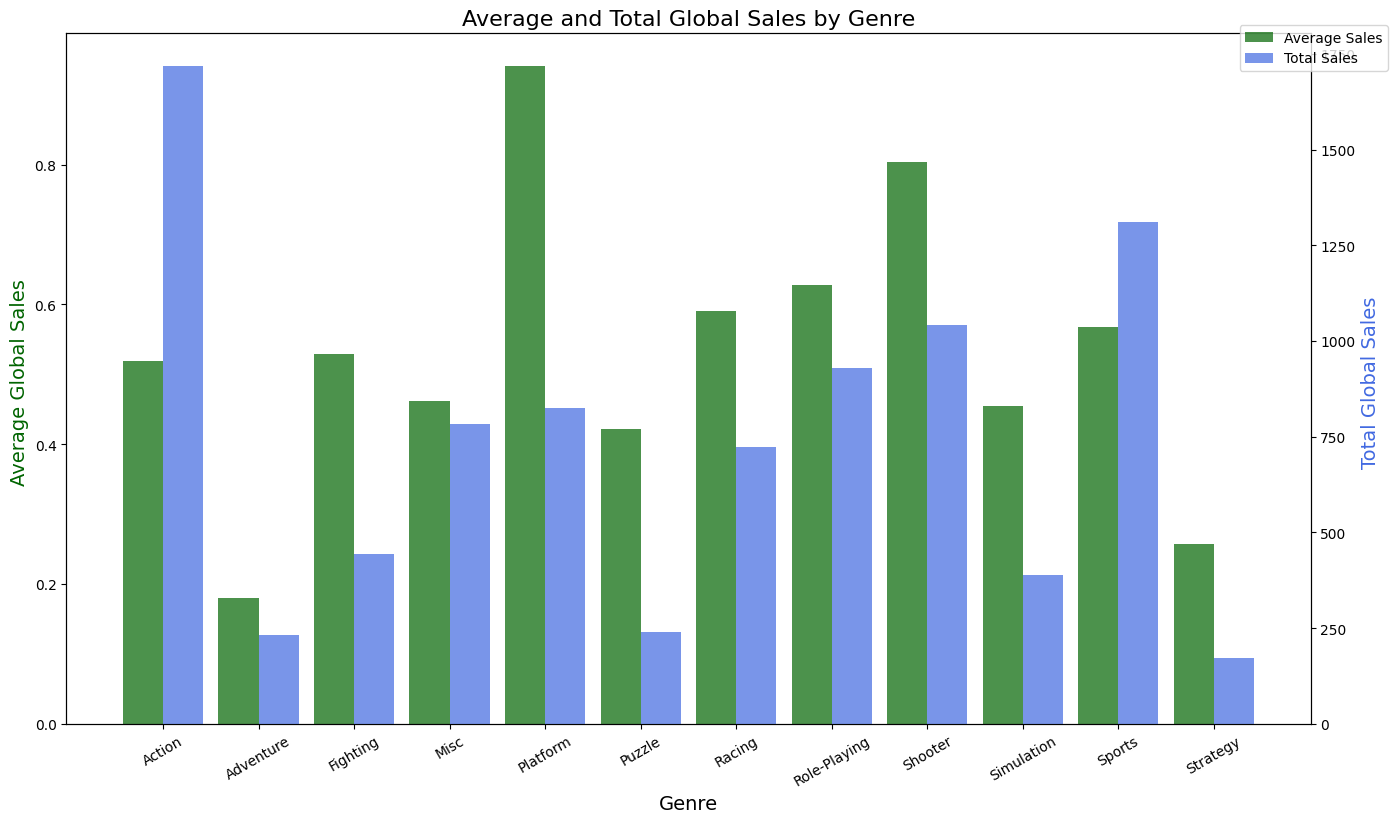

           Genre  Average Sales  Total Sales
0         Action       0.519389      1717.62
1      Adventure       0.180674       233.25
2       Fighting       0.528829       442.63
3           Misc       0.461514       783.19
4       Platform       0.940615       825.86
5         Puzzle       0.422373       240.33
6         Racing       0.590767       723.69
7   Role-Playing       0.627714       930.90
8        Shooter       0.803881      1041.83
9     Simulation       0.454058       388.22
10        Sports       0.568252      1310.39
11      Strategy       0.256979       172.69


In [ ]:
#Let's look at relative and total Global Sales by Genre. I wanted to combine both into one plot, so we needed to set up independent y-axes

#Calculate the metrics and combine
genre_avg_sales = finalgamesdf.groupby('Genre')['Global_Sales'].mean()
genre_total_sales = finalgamesdf.groupby('Genre')['Global_Sales'].sum()
combined_data = pd.DataFrame({
    'Average Sales': genre_avg_sales,
    'Total Sales': genre_total_sales
}).reset_index()
combined_data = combined_data.sort_values('Genre')

# Create figure and axes and bars
fig, ax1 = plt.subplots(figsize=(14, 8))
barWidth = 0.42
br1 = np.arange(len(combined_data))
br2 = [x + barWidth for x in br1]

# Average sales on first y-axis
ax1.set_xlabel('Genre', fontsize=14)
ax1.set_ylabel('Average Global Sales ', color='darkgreen', fontsize=14)
bars1 = ax1.bar(br1, combined_data['Average Sales'], width=barWidth, color='darkgreen', alpha=0.7, label='Average Sales')
ax1.tick_params(axis='y', labelcolor='black')
ax1.tick_params(axis='x', rotation=30)

# Total sales on second y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Total Global Sales ', color='royalblue', fontsize=14)
bars2 = ax2.bar(br2, combined_data['Total Sales'], width=barWidth, color='royalblue', alpha=0.7, label='Total Sales')
ax2.tick_params(axis='y', labelcolor='black')


plt.title('Average and Total Global Sales by Genre', fontsize=16)
fig.tight_layout()
fig.legend([bars1, bars2], ['Average Sales', 'Total Sales'], loc='upper right', bbox_to_anchor=(1, 0.97))

# Add x-tick labels at the correct positions
plt.xticks([r + barWidth/2 for r in range(len(combined_data))], combined_data['Genre'], rotation=10)

plt.show()

# Print the data for reference
print(combined_data[['Genre', 'Average Sales', 'Total Sales']])

In [ ]:
# Some interesting trends here. The Action Genre dominated total sales, but had a middling average sales.
# Conversely Platform games and Shooter games had high average sales but unremarkable total sales, perhaps
# signaling a market opportunity for a fledgling game studio.
# Strategy games (my favorite) and Adventure games sadly were very low in both categories.

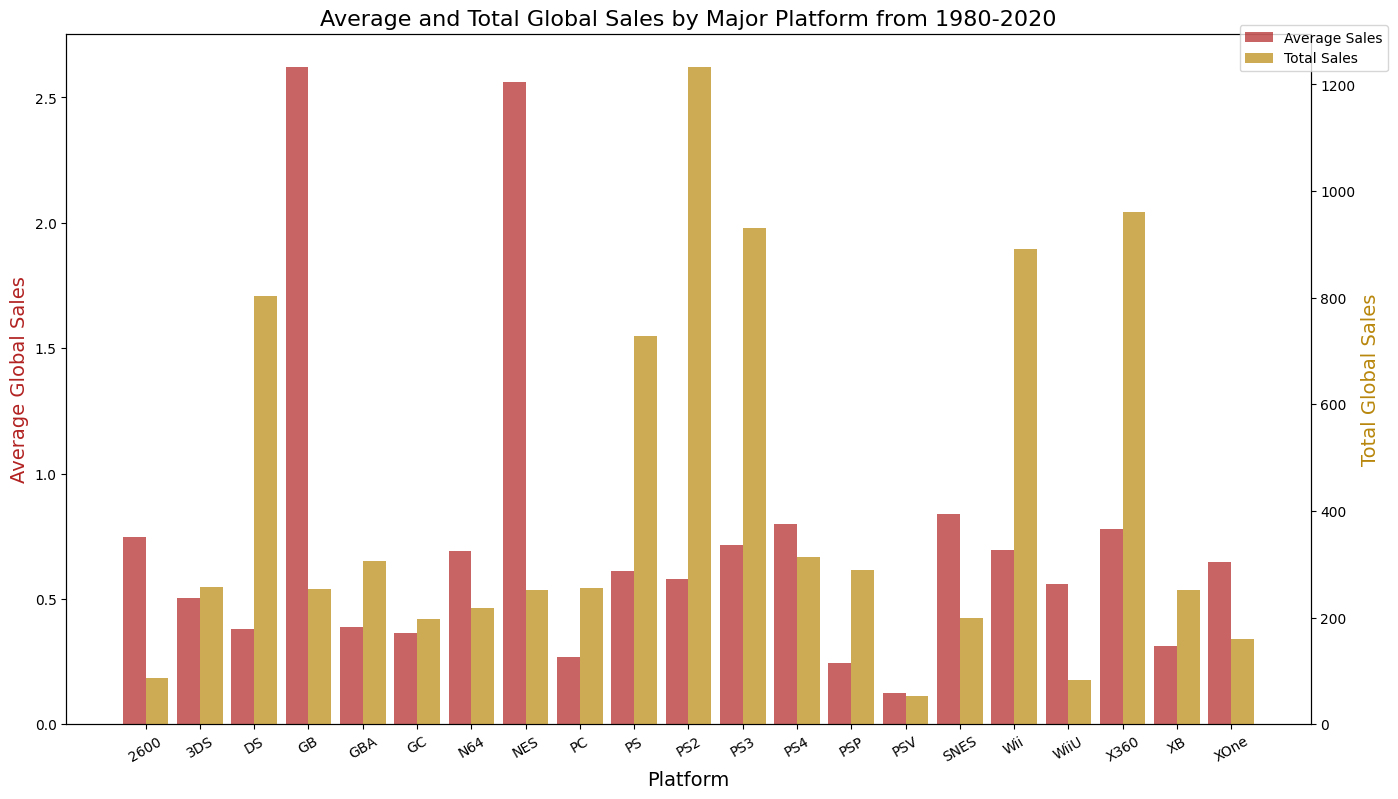

Platforms included in the chart:
   Platform  Average Sales  Total Sales
0      2600       0.746293        86.57
2       3DS       0.503750       257.92
4        DS       0.378761       803.73
5        GB       2.622887       254.42
6       GBA       0.388830       305.62
7        GC       0.363727       197.14
10      N64       0.690538       218.21
11      NES       2.561939       251.07
13       PC       0.269128       256.21
15       PS       0.611269       727.41
16      PS2       0.579906      1233.46
17      PS3       0.712979       931.15
18      PS4       0.799567       314.23
19      PSP       0.242909       289.79
20      PSV       0.125455        53.82
23     SNES       0.837029       200.05
26      Wii       0.693421       891.74
27     WiiU       0.558912        82.16
28     X360       0.780349       961.39
29       XB       0.313935       252.09
30     XOne       0.645506       159.44
The bottom 10 platforms in total Global Sales that did not make the cut:
['PCFX', 'GG',

In [ ]:
# Next I want to do a similar plot, but this time looking at what Platform the game was released on instead of Genre.
# Unlike the Genre variable where all of the values had significant data, many of the 30 unique Platforms had very tiny amounts of data,
# so i eliminated the bottom 10 (by total sales) of those Platforms.

# # Calculate the metrics and combine
platform_avg_sales = finalgamesdf.groupby('Platform')['Global_Sales'].mean()
platform_total_sales = finalgamesdf.groupby('Platform')['Global_Sales'].sum()
combined_data = pd.DataFrame({
    'Average Sales': platform_avg_sales,
    'Total Sales': platform_total_sales
}).reset_index()

# Remove the 10 smallest platforms by total global sales
sorted_by_total = combined_data.sort_values('Total Sales')
smallest_platforms = sorted_by_total.head(10)['Platform'].tolist()
filtered_data = combined_data[~combined_data['Platform'].isin(smallest_platforms)]

filtered_data = filtered_data.sort_values('Platform')

# Create figure and axes and bars
fig, ax1 = plt.subplots(figsize=(14, 8))
barWidth = 0.42
br1 = np.arange(len(filtered_data))
br2 = [x + barWidth for x in br1]

# Average sales on first y-axis
ax1.set_xlabel('Platform', fontsize=14)
ax1.set_ylabel('Average Global Sales', color='firebrick', fontsize=14)
bars1 = ax1.bar(br1, filtered_data['Average Sales'], width=barWidth, color='firebrick', alpha=0.7, label='Average Sales')
ax1.tick_params(axis='y', labelcolor='black')
ax1.tick_params(axis='x', rotation=30)

# Total sales on second y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Total Global Sales', color='darkgoldenrod', fontsize=14)
bars2 = ax2.bar(br2, filtered_data['Total Sales'], width=barWidth, color='darkgoldenrod', alpha=0.7, label='Total Sales')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Average and Total Global Sales by Major Platform from 1980-2020', fontsize=16)
fig.tight_layout()
fig.legend([bars1, bars2], ['Average Sales', 'Total Sales'], loc='upper right', bbox_to_anchor=(1, 0.97))

# Add x-tick labels at the correct positions
plt.xticks([r + barWidth/2 for r in range(len(filtered_data))], filtered_data['Platform'], rotation=10)

plt.show()

# Print the data for reference
print("Platforms included in the chart:")
print(filtered_data[['Platform', 'Average Sales', 'Total Sales']])

print("The bottom 10 platforms in total Global Sales that did not make the cut:")
print(smallest_platforms)

In [ ]:
# Some more interesting trends here. we see total global sales in the last four decades were dominated by six big players:
# the Nintendo DS, Playstation's 1, 2, and 3, the Wii, and the XBOX 360. The Playstation 2 sold the most.
# However, by far the two largest in average sales per game were the Nintendo Game Boy and NES. I think these earlier platforms were limited
# in the amount of games published, so on average their games were all very good sellers.

<Figure size 1600x1000 with 0 Axes>

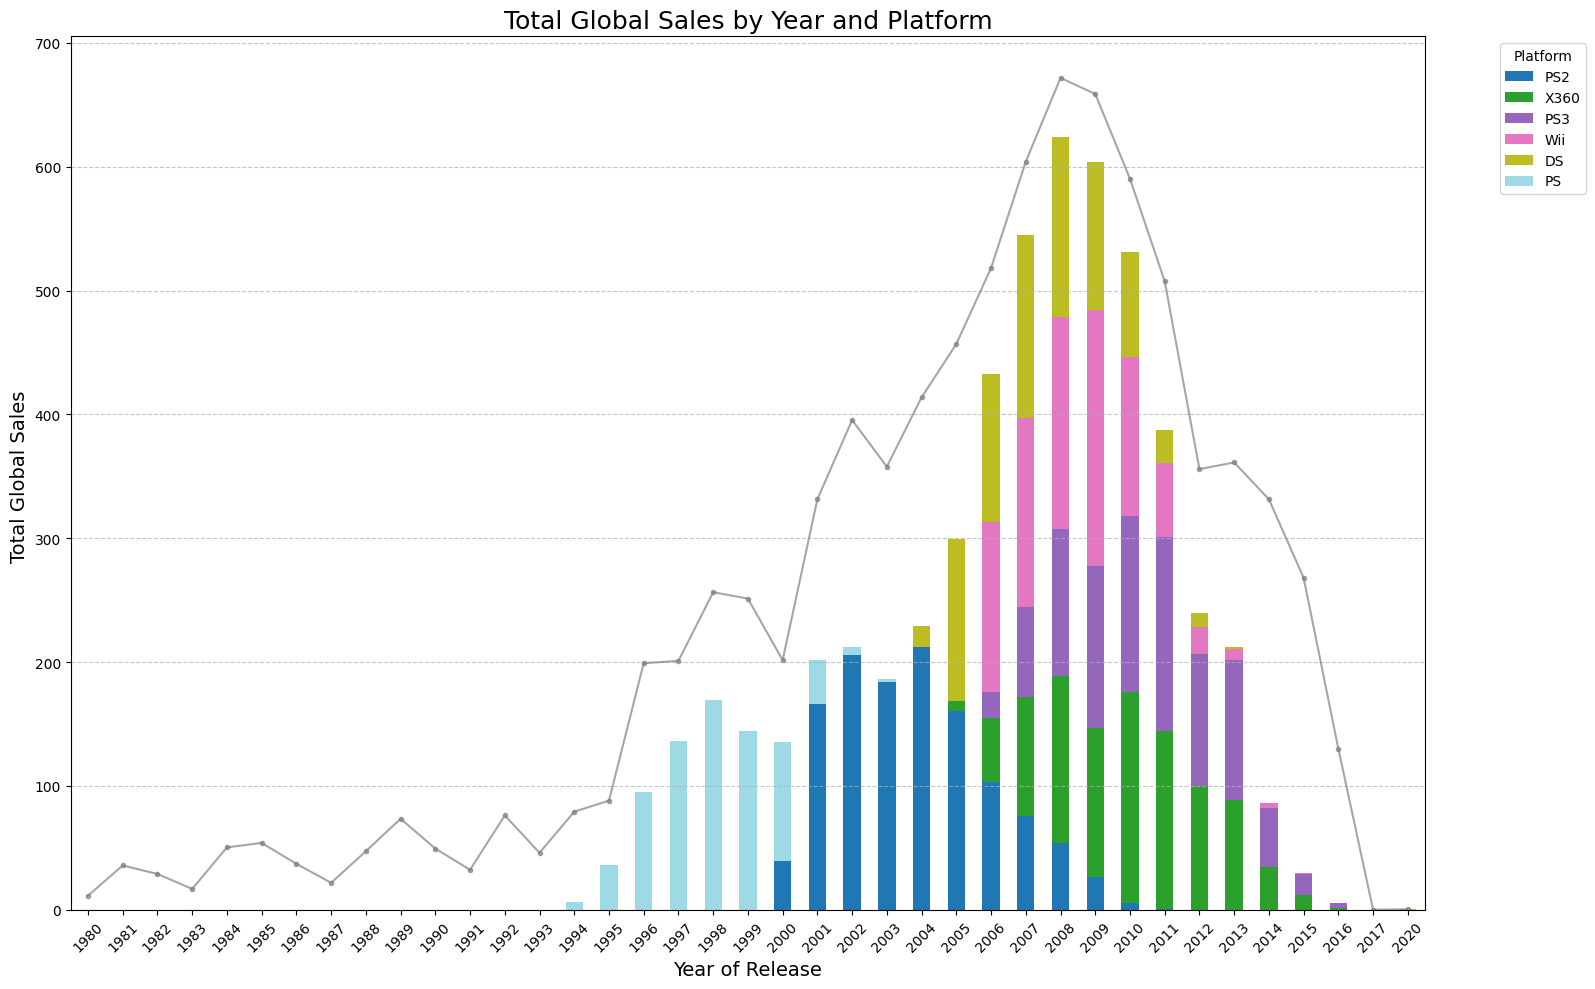

In [ ]:
# Finally, we want to look at how the video game market evolved through time. I want to look at a histogram of how global sales have evolved through time,
# coloring how each video game platform. Since we saw a distinct grouping above of the 6 highest selling platforms, let's limit this graph to those 6.

# group the data by Year_of_Release and Platform and sum Global_Sales (I did use chat gpt to help with this)
sales_by_year_platform = finalgamesdf.groupby(['Year_of_Release', 'Platform'])['Global_Sales'].sum().reset_index()
# create pivot table
pivot_data = sales_by_year_platform.pivot_table(
    index='Year_of_Release',
    columns='Platform',
    values='Global_Sales',
    aggfunc='sum',
    fill_value=0
)
total_sales_by_year = finalgamesdf.groupby('Year_of_Release')['Global_Sales'].sum().reset_index()

# For years stored as float, convert to int for cleaner display
if pivot_data.index.dtype == 'float64':
    pivot_data.index = pivot_data.index.astype(int)

# Sort the dataframe by year
pivot_data = pivot_data.sort_index()

# Limit it to the top 6
top_platforms = finalgamesdf.groupby('Platform')['Global_Sales'].sum().nlargest(6).index.tolist()
pivot_data_filtered = pivot_data[top_platforms]

# Create the stacked bar chart
plt.figure(figsize=(16, 10))
colors = plt.cm.tab20(np.linspace(0, 1, len(top_platforms)))

# Plot the stacked bars
pivot_data_filtered.plot(kind='bar', stacked=True, figsize=(16, 10), color=colors)
plt.title('Total Global Sales by Year and Platform', fontsize=18)
plt.xlabel('Year of Release', fontsize=14)
plt.ylabel('Total Global Sales ', fontsize=14)
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Since we only looking at the Top 6 Platforms by global sales, I didn't want to lose the context of the total combined sales of all platforms,
# So I added a grey line that represents the total market share of units sold.
years_in_pivot = pivot_data_filtered.index.tolist()
total_sales_filtered = total_sales_by_year[total_sales_by_year['Year_of_Release'].isin(years_in_pivot)]
total_sales_filtered = total_sales_filtered.sort_values('Year_of_Release')
x_positions = np.arange(len(years_in_pivot))  # Bar positions on x-axis
plt.plot(x_positions, total_sales_filtered['Global_Sales'],
        color='grey', linewidth=1.5, linestyle='-', alpha=0.7, marker='o', markersize=3,
        label='Total (All Platforms)')
# Ensure the layout is tight
plt.tight_layout()
plt.show()


In [ ]:
# Some very interesting data here. The first thing to note is that this is sales by Year of Release, not necesarrily by when the copy of
# each game was sold. We see that PlayStation 1 and PlayStation 2 existed largely in their own markets, while Nintendo DS, Wii, PlayStation 3 and XBOX 360
#all overlapped directly in the periods in which they released their peak units. Also, we can see that past 1995 these 6 platforms dominated the market,
# and Playstations 1 and 2 by themselves were half the market share for about a decade.
#

Correlation coefficient: 0.5794
P-value: 0.0000
Regression line: Critic_Score = 30.17 + 5.58 * User_Score


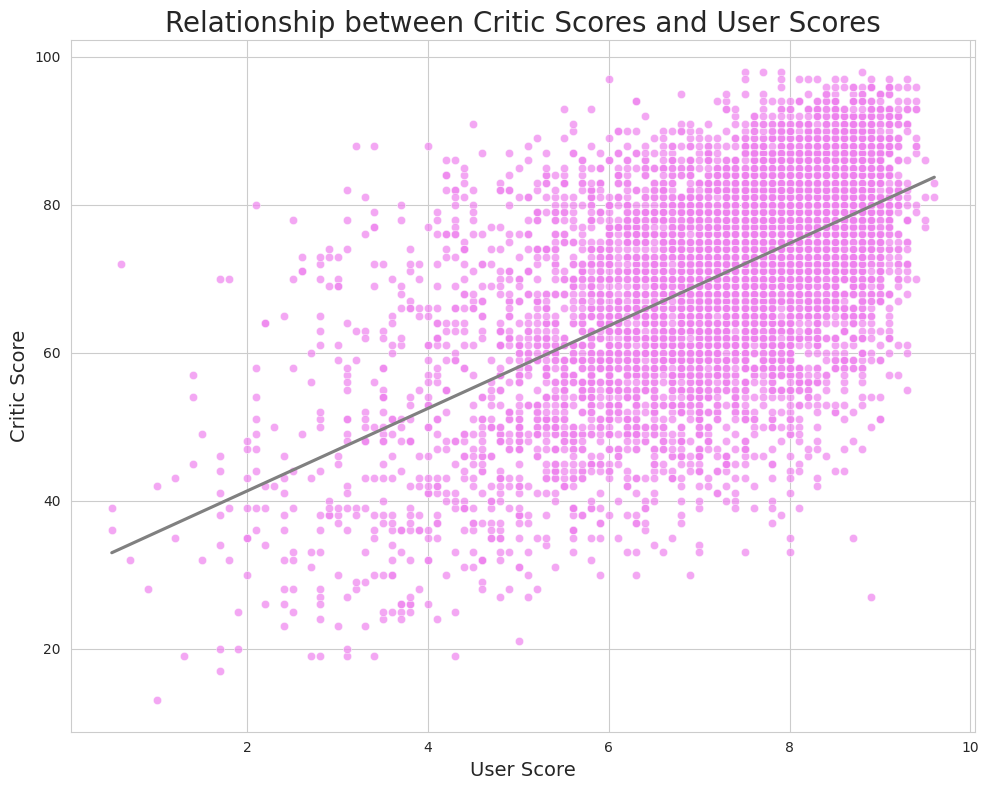

In [ ]:
# 3.2 Research Question 2: How do Critic Scores and User Scores correlate with respect to Publisher? Did they usually agree?
# Which Publishers had the best scores?

# First we want to simply plot the relationship between Critics and User Scores across all games and caluclate their rsquared value.
from scipy.stats import pearsonr
filtered_df = finalgamesdf.dropna(subset=['Critic_Score', 'User_Score'])
# calculate the correlation coefficient using pearsonr
correlation, p_value = pearsonr(filtered_df['User_Score'], filtered_df['Critic_Score'])
print(f"Correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")
# make scatterplot
plt.figure(figsize=(10, 8))
sns.set_style('whitegrid')
ax = sns.scatterplot(x='User_Score', y='Critic_Score', data=filtered_df, alpha=0.7, color="violet")

# Add regression line
sns.regplot(x='User_Score', y='Critic_Score', data=filtered_df,
            scatter=False, ci=None, line_kws={"color": "grey"})

# Calculate slope and intercept for displaying the equation
slope, intercept = np.polyfit(filtered_df['User_Score'], filtered_df['Critic_Score'], 1)
print(f"Regression line: Critic_Score = {intercept:.2f} + {slope:.2f} * User_Score")

# Styling the plot
plt.title('Relationship between Critic Scores and User Scores', fontsize=20)
plt.xlabel('User Score', fontsize=14)
plt.ylabel('Critic Score', fontsize=14)
plt.tight_layout()
# Show the plot
plt.show()


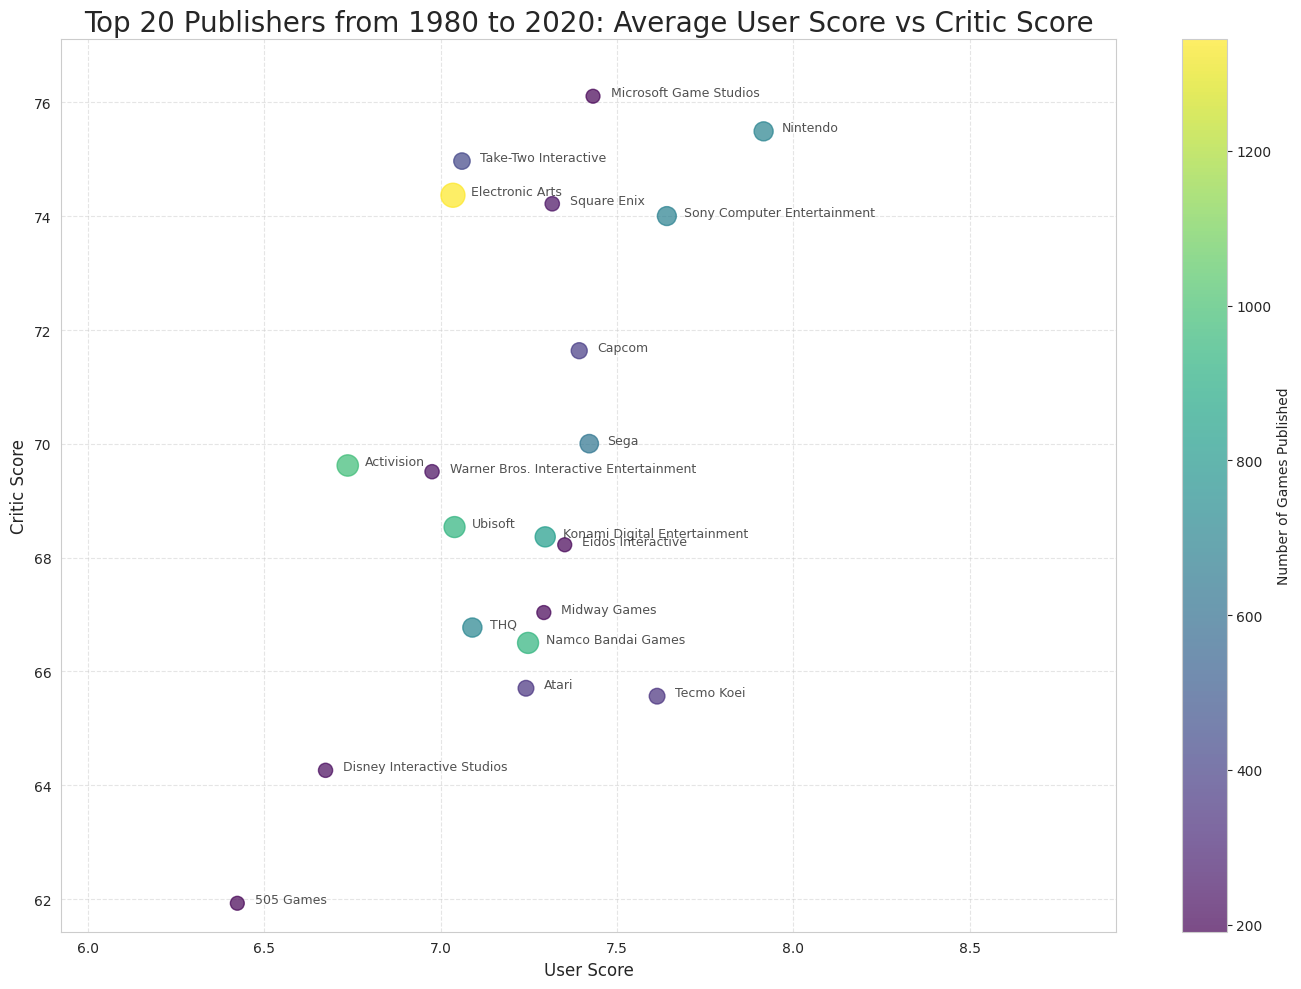

In [ ]:

# I really wanted to create a high quality infographic here, that showed
# the relationship between Publisher, Number of Games Published, Critic Scores and User Scores.

# We needed to first filter by only the 20 most common publishers, otherwise the plot was too noisy
top_publishers = finalgamesdf['Publisher'].value_counts().head(20).index.tolist()
filtered_df = finalgamesdf[finalgamesdf['Publisher'].isin(top_publishers)]

# group by Publisher and calculate mean scores of their critic scores and user scores
publisher_scores = filtered_df.groupby('Publisher')[['Critic_Score', 'User_Score']].mean().reset_index()

# We also want a 4th dimension that is the number of games published by each publisher
publisher_counts = filtered_df['Publisher'].value_counts().reset_index()
publisher_counts.columns = ['Publisher', 'Count']

# Merge the scores with the counts
publisher_data = pd.merge(publisher_scores, publisher_counts, on='Publisher')

# build the plot
plt.figure(figsize=(14, 10))

# Normalize the counts for point sizing (between 100 and 300) (Used chatgpt here for help)
min_count = publisher_data['Count'].min()
max_count = publisher_data['Count'].max()
publisher_data['Size'] = 100 + (publisher_data['Count'] - min_count) * 200 / (max_count - min_count)

# Plot each publisher as a point with size proportional to number of games
scatter = plt.scatter(
    publisher_data['User_Score'],
    publisher_data['Critic_Score'],
    s=publisher_data['Size'],
    alpha=0.7,
    c=publisher_data['Count'],  # Color by count
    cmap='viridis'  # Use a color map
)

# Add publisher labels to each point
for i, row in publisher_data.iterrows():
    plt.text(
        row['User_Score'] + 0.05,  # Add small offset for readability
        row['Critic_Score'],
        row['Publisher'],
        fontsize=9,
        alpha=0.8
    )

# Add title and labels
plt.title('Top 20 Publishers from 1980 to 2020: Average User Score vs Critic Score', fontsize=20)
plt.xlabel('User Score', fontsize=12)
plt.ylabel('Critic Score', fontsize=12)

# Add a colorbar to show the count scale
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Games Published')

# Add grid for easier reading
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust axis limits for better visualization
plt.xlim(publisher_data['User_Score'].min() - 0.5, publisher_data['User_Score'].max() + 1)
plt.ylim(publisher_data['Critic_Score'].min() - 0.5, publisher_data['Critic_Score'].max() + 1)

plt.tight_layout()
plt.show()

In [ ]:
# Research Question 2 Conclusions: We see there is an extremely significant (pvalue <.001) positive relationship between Critic Scores
# and User Scores, although the correlation coefficient (.5794) is not as direct as one would think.
# There is still some differentiation between the two, it is not a perfect correlation.
# Also, we see the Critic Scores and User Scores of our top 20 publishers: Nintendo was highly praised by both groups, while
# Microsoft yielded particularly high Critic Scores while Sony and Tecmo Koei had pretty high User Scores. 505 Games produced the
# worst rated games by both metrics, and Disney Interactive Studios the second worst by both metrics.

In [ ]:
# 3.3 Research Question 3: Can we use machine learning to predict the ESBR rating of a Video Game from its numerical variables?
# Which Classification algorithm works best between decision tree / log regression / Naive Bayes ?

# We want to see if we can accurately predict a video games ESBR rating from its numerical variables, so the first step is to
# trim our dataset to only include those with an ESBR rating, which we will store in dataframe ratingsdf
# Afterwards, we could use our classification to predict some games whose ratings were missing!

ratingsdf = finalgamesdf.dropna(subset=['Rating'])
# check
print(f"finalgamesdf size {finalgamesdf.shape}")
print(f"ratingsdf size {ratingsdf.shape}")


rating_counts = ratingsdf['Rating'].value_counts()
print("Rating values:")
print(rating_counts)
print("Therefore our accuracy baseline is 3921/9769= .40145 from guessing E everytime")


finalgamesdf size (16416, 22)
ratingsdf size (9767, 22)
Rating values:
Rating
E       3921
T       2904
M       1536
E10+    1393
EC         8
K-A        3
AO         1
RP         1
Name: count, dtype: int64
Therefore our accuracy baseline is 3921/9769= .40145 from guessing E everytime


In [ ]:
# Then we prepare the input fields, target variables, test/train sets with an 80/20 split
X = ratingsdf.drop(columns=['Rating', 'Name', 'Platform', 'Genre', 'Publisher', 'Developer'])
y = ratingsdf['Rating']

# we print the shapes to verify it worked
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1235746)
#again print the shapes to check
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X shape: (9767, 16)
y shape: (9767,)
X_train shape: (7813, 16)
X_test shape: (1954, 16)
y_train shape: (7813,)
y_test shape: (1954,)


In [ ]:
# 3.3.2 Decision Tree Classifier
clf_1 = DecisionTreeClassifier(random_state=123643)

#Fitting our classifier
clf_1.fit(X_train, y_train)
print(clf_1)

#Generating train/test predictions
predictions_train1 = clf_1.predict(X_train)
print(predictions_train1)
predictions_test1 = clf_1.predict(X_test)
print(predictions_test1)

#Accuracy Scores for Train/Test
trainingacc = accuracy_score(y_train, predictions_train1)
print(f'Our training accuracy is {trainingacc:.4f}')

testacc = accuracy_score(y_test, predictions_test1)
print(f'Our testing accuracy is {testacc:.4f}')

DecisionTreeClassifier(random_state=123643)
['E' 'E10+' 'E10+' ... 'M' 'E10+' 'E10+']
['T' 'T' 'T' ... 'E' 'E' 'E']
Our training accuracy is 0.9811
Our testing accuracy is 0.4483


In [ ]:
# We see our decision tree is extremely overfit, witha  training accuracy of near perfect but a testing accuracy of .4483.
# This testing accuracy is not much better than guessing E everytime (.40145), but it is slightly better.
# I wonder if dropping the superfluous sales variables will improve the overfitting problem? Lets try it once

X2 = ratingsdf.drop(columns=['Rating', 'Name', 'Platform', 'Genre', 'Publisher', 'Developer', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])
y2 = ratingsdf['Rating']
# we print the shapes to verify it worked
print(f'X shape: {X2.shape}')
print(f'y shape: {y2.shape}')

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=1235746)
#again print the shapes to check
print(f'X_train shape: {X_train2.shape}')
print(f'X_test shape: {X_test2.shape}')
print(f'y_train shape: {y_train2.shape}')
print(f'y_test shape: {y_test2.shape}')
clf_1_2 = DecisionTreeClassifier(random_state=123643)

#Fitting our classifier
clf_1_2.fit(X_train2, y_train2)
print(clf_1_2)

#Generating train/test predictions
predictions_train1_2 = clf_1_2.predict(X_train2)
print(predictions_train1_2)
predictions_test1_2 = clf_1_2.predict(X_test2)
print(predictions_test1_2)

#Accuracy Scores for Train/Test
trainingacc2 = accuracy_score(y_train2, predictions_train1_2)
print(f'Our training accuracy is {trainingacc2:.4f}')

testacc2 = accuracy_score(y_test2, predictions_test1_2)
print(f'Our testing accuracy is {testacc2:.4f}')

X shape: (9767, 12)
y shape: (9767,)
X_train shape: (7813, 12)
X_test shape: (1954, 12)
y_train shape: (7813,)
y_test shape: (1954,)
DecisionTreeClassifier(random_state=123643)
['E' 'E10+' 'E10+' ... 'M' 'E10+' 'E10+']
['T' 'T' 'T' ... 'T' 'E' 'E']
Our training accuracy is 0.9825
Our testing accuracy is 0.4473


In [ ]:
# Sadly, removing the superfluous Sales varaibles variables did not help our testing accuracy score at all. We will not try that again

In [ ]:
# 3.3.3 Logistic Regression Classifier
from sklearn.linear_model import LogisticRegression
clf_2 = LogisticRegression(random_state=12353345, max_iter=10000)
# We need to remove all NA values if we want to proceed with Logistic regression
ratingsclean = ratingsdf.dropna()
X3 = ratingsclean.drop(columns=['Rating', 'Name', 'Platform', 'Genre', 'Publisher', 'Developer'])
y3 = ratingsclean['Rating']
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=1235746)
#again print the shapes to check
print(f'X_train shape: {X_train3.shape}')
print(f'X_test shape: {X_test3.shape}')
print(f'y_train shape: {y_train3.shape}')
print(f'y_test shape: {y_test3.shape}')
clf_2.fit(X_train3, y_train3)
print(clf_2)
#Generate predictions for train and test
predictions_train2 = clf_2.predict(X_train3)
print(predictions_train2)
predictions_test2 = clf_2.predict(X_test3)
print(predictions_test2)

# then calculate Accuracies
trainacclog3 = accuracy_score(y_train3, predictions_train2)
print(trainacclog3)
testacclog3 = accuracy_score(y_test3, predictions_test2)
print(testacclog3)

X_train shape: (5460, 16)
X_test shape: (1365, 16)
y_train shape: (5460,)
y_test shape: (1365,)
LogisticRegression(max_iter=10000, random_state=12353345)
['E' 'T' 'T' ... 'T' 'T' 'M']
['E' 'E' 'E' ... 'E' 'T' 'E']
0.4758241758241758
0.5091575091575091


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Interestingly, our logistic regression model was underfit, with a training accuracy of .4758
# but a test accuracy of .5091. This is fairly better than our guessing model, so we can conclude our logistic classifier
# is at least somewhat helpful in predicting ESBR rating.

In [ ]:
# 3.3.4 Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB
clf_4 = GaussianNB()
# We're going to fit our Naive Bayes on the set without missingness, like we did with logistic
clf_4.fit(X_train3, y_train3)
trainpred_nb = clf_4.predict(X_train3)
testpred_nb = clf_4.predict(X_test3)
trainaccnb = accuracy_score(y_train3, trainpred_nb)
testaccnb = accuracy_score(y_test3, testpred_nb)
print(trainaccnb, "is our training accuracy")
print(testaccnb, "is our testing accuracy")

0.38168498168498166 is our training accuracy
0.39194139194139194 is our testing accuracy


In [ ]:
# Research Question 3 Conclusions: While we were able to see slight improvements in training Classifier models on our dataset, it
# was overall very hard to predict ESBR rating from the other numerical variables.
# Our Naive Bayes Classifier test accuracy is the lowest of the three at .39194 (and was WORSE than random guessing). I suspect this is due to the extremely skewed numeric variables
# with many outliers. Logistic Regression was our best classification model with a respectable .50915 testing accuracy,
# and the decision tree in the middle with a testing accuracy of .4483.
# Given that our benchmark accuracy of guessing E everytime was .40145, I think it would be useful to use our Logistic Regression model (test accuracy of .50915) to
# predict ESBR ratings for games that either did not recieve a rating or had not yet been rated.

### Step 4:  Present your findings

In this step, you can begin to report your findings.  What did you learn from the data and how do your findings help answer your research question?

This includes following all best practices for presenting your findings that you learnt during the mini-project. The report should be easy to read and important points and explanations clearly highlighted.

__Remember:__ Rarely will a single data analysis conclusively answer a research question.  Here, you need to identify possible limitations.  For example, are your results limited to a certain area, city, or country?  Are you making assumptions about the data which may, or may not, be valid (e.g., that students in one term are equally qualified as students in another)?  Document these limitations in a few paragraphs.


In [ ]:
#EXPAND THIS SECTION TO PRESENT YOUR FINDINGS

# Initial Data Exploration Conclusions
# I initially dove into the Video Game Sales dataset knowing nothing about it, and have learned quite a lot from this exploratory data analysis.
# We also used a variety of python libraries in this analysis, which helped us conscisely learn things about our data. Our preliminary survey of the
# data showed us we had a mix of numerical and character variables and a mix of no, a few missing, and many missing values within these variables. We
# decided to deal with these in different ways: eliminating the small amount of values in the Name, Year, Genre and Publisher variables, but accepting the
# missing values in the Score/Developer/Rating variables and working with it. Next we looked at the distributions of our character values, learning that
# PS2 and Nintendo DS were the most common  platforms in terms of games released, Action and Sports games most released,  and EA was the most
# common publisher while Ubisoft is the single most common developer. Then a look at our numerical variables showed us that the variables
# Year_of_Release, Critic_Score, Critic_Count, and User_Score all had easily interpretable distributions, while othe other numerical variables
# were extremely skewed and had to be dealt with with a log transform. Additionally, game sales are extremely unequal, and most of the video games
# in our dataset sold very few copies while a handful of games sold extremely well.
#
# Research Question 1 Conclusions
# Which factors contributed to the Global_Sales variable and are good targets for market reseach?
# We learned that Global Sales were affected strongly# by the game's Publisher, Genre, and Year of Release.
# The Action Genre dominated total sales while Platform games and Shooter games had high average sales,
# and Strategy and Adventure games struggled in both. We saw that total global video game sales in the last four decades were dominated by six platforms:
# the Nintendo DS, Playstation's 1, 2, and 3, the Wii, and the XBOX 360, with the the Playstation 2 selling the most. Finally, we observed how these six platform's
# sales interacted with each other and the market as a whole over time, with video game sales peaking in 2008.


# Research Question 2 Conclusions
# How do Critic Scores and User Scores correlate with respect to Publisher? Did they usually agree? # Which Publishers had the best scores?
# We learned that Critic Scores and User Scores, how highly the two groups rate the performance of each individual game, had a strong positive porrelation
# (pearson coefficient of .5794). Also, we saw the Critic Scores and User Scores of our top 20 publishers and learned that Nintendo was highly praised by both groups.
# Microsoft yielded particularly high Critic Scores while Sony and Tecmo Koei had pretty high User Scores. 505 Games and Disney Interactive Studios consistently produced
# the lowest rated games by both metrics, well below their peers.
#

# Research Question 3 Conclusions
# Can we use machine learning to predict the ESBR rating of a Video Game from its numerical variables?
# Which Classification algorithm works best between decision tree / log regression / Naive Bayes ?
# This Research Question did not go as succesfully as the previous two, but still leaded to some valuable insights about the limits of our dataset. We were succesfull in getting
# a classification algorithm working by using a Decision Tree, Logistic Regression, and Naive Bayes approach, all of which required different data modifications and tunings.
# However, the test accuracy of three models were not particularly supportive. For context, our benchmark accuracy of was .40145. Our Naive Bayes yielded an abysmal accuracy of .39194,
# and the decision tree was not much better at .4483. However our Logistic Regression classifier yielded a test accuracy of .50915,
# meaning it would be at least somewhat helpful at predicting the ESBR ratings of video games based on their numeric input variables.

# 2. Video

Make a video where you go over each part of the report speaking about the steps you undertook and explaining your work, reasonings, insights and highlighting the important points of the project. You do not need to explain the lines of code (unless you feel it is required).

1. The video should be more than 5 minutes and strictly less than 10 minutes.
2. Both audio and video is required.
3. You can use the zoom to record the video. Start a meeting, start video, start recording and share screen.
4. Make sure your audio is clear before uploading the video to the gradescope.


Additionally (and this is important), ensure you follow the format the video submission. If one of these criteria is missing, we will not grade the video.
* Show some form of ID at the start of the video so we know who you are.
* Show your code in the video by screensharing.
* Show your face in the video.


In [ ]:
#          https://drive.google.com/file/d/1X5h0yW7bGOqDnlcWarXIYCOROoJf8-iC/view?usp=sharing

# Here is the video, a share link from my google drive with permissions for anyone with the link
# it was just barely over ten minutes and I apologize, I probably could have talked for an hour!

SyntaxError: invalid decimal literal (<ipython-input-40-61553bb98e0a>, line 1)